# Mod C - Week 5 | Support Vector Machines 

Use Support Vector Machines (SVM) on the Capstone datasets to build and evaluate classification models. The process will include scaling the features for better performance, training SVM models with different kernels (linear, polynomial, and RBF), and measuring results with metrics like accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC.And also tune key parameters, such as C and gamma, to find the right balance between margin size and classification accuracy.

# Capstone Project: Cybersecurity - Network Threat Detection using Anomaly detection and attack classification
The three datasets under use are 
1. BETH dataset – Contains network traffic records labeled for different attack types, focusing on distinguishing benign vs. malicious activities.
2. Cybersecurity Attacks dataset – Provides additional records of real-world attack behaviors, enabling comparison and model generalization across datasets.
3. UNSW-NB15 dataset – A widely used benchmark dataset for network intrusion detection, including features such as packet statistics, byte counts, and flow information, with multiple classes of cyberattacks.

#### Imports and Load datasets from kaggle

In [2]:
## General libraries 
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys 

### Libraries for train test split and models

from sklearn.preprocessing import LabelEncoder
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error,ConfusionMatrixDisplay, confusion_matrix, accuracy_score, f1_score

  
#########  Linraies for Logistic Regression regression
 
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import f1_score, mean_squared_error

random_state = 0

#####################  Libraries for SVM #####################
from sklearn.svm import OneClassSVM, SVC,LinearSVC
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.metrics import roc_curve, auc 

# Optional: make plots nicer
%matplotlib inline
sns.set(style="whitegrid")

## LOAD DATASETS and specific libraries
 
import kagglehub
import os

# DATASET 1 :  BETH cyberseurity dataset
beth_dataset_path = kagglehub.dataset_download("katehighnam/beth-dataset")
print("Path to dataset files:", beth_dataset_path)
print(os.listdir(beth_dataset_path))
kernel_files = [
    "labelled_training_data.csv",
    "labelled_validation_data.csv",
    "labelled_testing_data.csv"
]
dataframes = [pd.read_csv(os.path.join(beth_dataset_path, file)) for file in kernel_files]
df_beth_merged = pd.concat(dataframes, ignore_index=True)


# DATASET 2: Cybersecurity Dataset
CSA_dataset_path = kagglehub.dataset_download("teamincribo/cyber-security-attacks")
print("Path to dataset files:", CSA_dataset_path)
print(os.listdir(CSA_dataset_path))
csa_csv_path = os.path.join(CSA_dataset_path, "cybersecurity_attacks.csv")
df_csa = pd.read_csv(csa_csv_path)


# DATASET 3 : UNSW-NB15 Intrusion Detection Dataset
path = kagglehub.dataset_download("dhoogla/unswnb15")
df_unsw= pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))


c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\katehighnam\beth-dataset\versions\3
['labelled_2021may-ip-10-100-1-105-dns.csv', 'labelled_2021may-ip-10-100-1-105.csv', 'labelled_2021may-ip-10-100-1-186-dns.csv', 'labelled_2021may-ip-10-100-1-186.csv', 'labelled_2021may-ip-10-100-1-26-dns.csv', 'labelled_2021may-ip-10-100-1-26.csv', 'labelled_2021may-ip-10-100-1-4-dns.csv', 'labelled_2021may-ip-10-100-1-4.csv', 'labelled_2021may-ip-10-100-1-95-dns.csv', 'labelled_2021may-ip-10-100-1-95.csv', 'labelled_2021may-ubuntu-dns.csv', 'labelled_2021may-ubuntu.csv', 'labelled_testing_data.csv', 'labelled_training_data.csv', 'labelled_validation_data.csv']
Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\teamincribo\cyber-security-attacks\versions\23
['cybersecurity_attacks.csv', 'README.md']


## Dataset 1: BETH Cybersecurity dataset
#### (i) Exploratory Data analysis  

In [3]:

# Encode categorical features to numerical features using label encoder to allow regression modelling
numeric_columns_beth = df_beth_merged.select_dtypes(include=['number']).columns
categorical_columns_beth = df_beth_merged.select_dtypes(include=['object']).columns
le_dict = {}
for col in categorical_columns_beth:
    le_dict[col] = LabelEncoder()
    df_beth_merged[col] = le_dict[col].fit_transform(df_beth_merged[col])
# Verify and split the datset 
df_train_val,df_test = train_test_split(df_beth_merged, test_size=0.2, stratify=df_beth_merged['evil'], random_state=42)
df_beth, df_val = train_test_split(df_train_val, test_size=0.25, stratify=df_train_val['evil'], random_state=42)
#data cleaning
df_beth.head()
print(f"Null values: {df_beth.isnull().sum()}")
print(f"Shape of the DataFrame: {df_beth.shape}")

numeric_columns_beth = df_beth.select_dtypes(include=['number']).columns
print (f"numeric columns: \n{numeric_columns_beth}")

categorical_columns_beth = df_beth.select_dtypes(include=['object']).columns
print(f"categorical columns: \n {categorical_columns_beth}")


#######################  Assign features and target ################################################################################3
# Features and target (using 'evil' as the target variable)Although the primary target (evil) is binary, 
# we focus on applying linear regression techniques on continuous features to understand model concepts like multicollinearity and interaction effects.
##################################################################################################################################
X_train_beth = df_beth.drop(['evil','sus'],axis=1)
y_train_beth = df_beth['evil']
 
X_val_beth = df_val.drop(['evil', 'sus'], axis=1)
y_val_beth = df_val['evil']

X_test_beth = df_test.drop(['evil', 'sus'], axis=1)
y_test_beth = df_test['evil']


###############################################################Regularize features #################################3
regularize = StandardScaler()
X_train_beth_reg = regularize.fit_transform(X_train_beth)
X_test_beth_reg = regularize.transform(X_test_beth)

X_train_beth_df = pd.DataFrame(X_train_beth, columns=X_train_beth.columns)
X_train_beth_reg_df = pd.DataFrame(X_train_beth_reg, columns=X_train_beth.columns)
X_test_beth_df = pd.DataFrame(X_test_beth, columns=X_test_beth.columns)
X_test_beth_reg_df = pd.DataFrame(X_test_beth_reg, columns=X_test_beth.columns)

########################################Normalize  features################################################################

norm = MinMaxScaler()
X_train_beth_norm= norm.fit_transform(X_train_beth)
X_test_beth_norm = norm.transform(X_test_beth)

# Convert scaled features back to DataFrames
X_train_beth_df = pd.DataFrame(X_train_beth, columns=X_train_beth.columns)
X_train_beth_norm_df = pd.DataFrame(X_train_beth_norm, columns=X_train_beth.columns)
X_test_beth_df = pd.DataFrame(X_test_beth, columns=X_test_beth.columns)
X_test_beth_norm_df = pd.DataFrame(X_test_beth_norm, columns=X_test_beth.columns)
 
       

Null values: timestamp          0
processId          0
threadId           0
parentProcessId    0
userId             0
mountNamespace     0
processName        0
hostName           0
eventId            0
eventName          0
stackAddresses     0
argsNum            0
returnValue        0
args               0
sus                0
evil               0
dtype: int64
Shape of the DataFrame: (684646, 16)
numeric columns: 
Index(['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId',
       'mountNamespace', 'processName', 'hostName', 'eventId', 'eventName',
       'stackAddresses', 'argsNum', 'returnValue', 'args', 'sus', 'evil'],
      dtype='object')
categorical columns: 
 Index([], dtype='object')


# SVM 

=== One-Class SVM (Anomaly Detection) ===
Accuracy: 0.9521
Precision: 0.7394911504424779
Recall: 0.9940520446096655
F1-Score: 0.848081192515065
ROC-AUC: 0.9698163169322158
Confusion Matrix:
 [[8184  471]
 [   8 1337]]

=== Supervised SVM with linear kernel (GridSearchCV) ===
Best Hyperparameters: {'C': 0.01}
Accuracy: 0.9986
Precision: 0.998501872659176
Recall: 0.9910780669144982
F1-Score: 0.994776119402985
ROC-AUC: 0.9999199379777038
Confusion Matrix:
 [[8653    2]
 [  12 1333]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      8655
           1       1.00      0.99      0.99      1345

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000


=== Supervised SVM with poly kernel (GridSearchCV) ===
Best Hyperparameters: {'C': 0.1, 'degree': 2, 'gamma': 0.1}
Accuracy: 0.9986
Precision: 0.998501872659176
Re

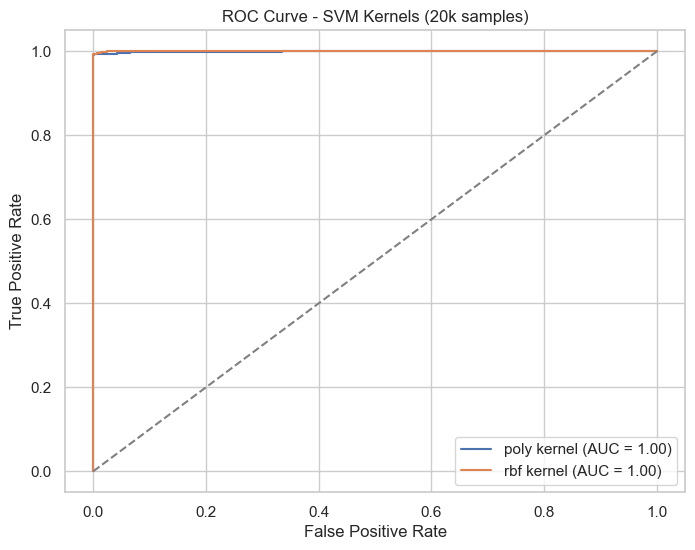

In [10]:
from sklearn.svm import SVC, OneClassSVM
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, auc)
import matplotlib.pyplot as plt
import numpy as np

# =========================================
# BETH Dataset - SVM Workflow (20,000 samples)
# =========================================

# ------------------ 0. Subsample for faster execution ------------------
sample_size = 10000
X_train_small = X_train_beth_reg[:sample_size]
y_train_small = y_train_beth[:sample_size]
X_test_small = X_test_beth_reg[:sample_size]
y_test_small = y_test_beth[:sample_size]

# =========================================
# 1. Anomaly Detection with One-Class SVM
# =========================================
X_benign = X_train_small[y_train_small == 0]  # train only on benign data

oneclass_svm = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
oneclass_svm.fit(X_benign)

y_pred_ocsvm = oneclass_svm.predict(X_test_small)
y_pred_ocsvm = np.where(y_pred_ocsvm == 1, 0, 1)  # 0=benign, 1=anomaly

print("=== One-Class SVM (Anomaly Detection) ===")
print("Accuracy:", accuracy_score(y_test_small, y_pred_ocsvm))
print("Precision:", precision_score(y_test_small, y_pred_ocsvm))
print("Recall:", recall_score(y_test_small, y_pred_ocsvm))
print("F1-Score:", f1_score(y_test_small, y_pred_ocsvm))
print("ROC-AUC:", roc_auc_score(y_test_small, y_pred_ocsvm))
print("Confusion Matrix:\n", confusion_matrix(y_test_small, y_pred_ocsvm))

# =========================================
# 2. Attack Classification with Supervised SVM (GridSearchCV)
# =========================================
kernels = ['linear', 'poly', 'rbf']
results = {}
fitted_clfs = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'linear': {'C': [0.01, 0.1, 1, 10]},
    'poly': {'C': [0.01, 0.1, 1, 10], 'gamma': [0.01, 0.1, 1], 'degree': [2, 3]},
    'rbf': {'C': [0.01, 0.1, 1, 10], 'gamma': [0.01, 0.1, 1]}
}

for kernel in kernels:
    if kernel == 'linear':
        svc = SVC(kernel='linear', probability=True, random_state=42)
    else:
        svc = SVC(kernel=kernel, probability=True, random_state=42)

    grid = GridSearchCV(estimator=svc, param_grid=param_grid[kernel], 
                        cv=cv, scoring='f1', n_jobs=-1)
    grid.fit(X_train_small, y_train_small)

    clf = grid.best_estimator_
    y_pred = clf.predict(X_test_small)
    y_prob = clf.predict_proba(X_test_small)[:,1]

    fitted_clfs[kernel] = clf
    results[kernel] = {
        'Best Params': grid.best_params_,
        'Accuracy': accuracy_score(y_test_small, y_pred),
        'Precision': precision_score(y_test_small, y_pred),
        'Recall': recall_score(y_test_small, y_pred),
        'F1-Score': f1_score(y_test_small, y_pred),
        'Confusion Matrix': confusion_matrix(y_test_small, y_pred),
        'Report': classification_report(y_test_small, y_pred),
        'ROC-AUC': roc_auc_score(y_test_small, y_prob)
    }

# Print results
for kernel, metrics in results.items():
    print(f"\n=== Supervised SVM with {kernel} kernel (GridSearchCV) ===")
    print("Best Hyperparameters:", metrics['Best Params'])
    for k, v in metrics.items():
        if k not in ['Confusion Matrix','Report','Best Params']:
            print(f"{k}: {v}")
    print("Confusion Matrix:\n", metrics['Confusion Matrix'])
    print("Classification Report:\n", metrics['Report'])

# =========================================
# 3. ROC Curves for Poly and RBF kernels
# =========================================
plt.figure(figsize=(8,6))

for kernel in ['poly','rbf']:
    clf = fitted_clfs[kernel]
    y_prob = clf.predict_proba(X_test_small)[:,1]
    fpr, tpr, _ = roc_curve(y_test_small, y_prob)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{kernel} kernel (AUC = {roc_auc_val:.2f})')

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM Kernels (20k samples)')
plt.legend()
plt.show()


## Dataset 2: Cybersecurity dataset
#### (i) Exploratory Data analysis

In [11]:


# Drop unnecessary columns
cols_to_dropcsa = ['Source IP Address','Destination IP Address','User Information', 
                    'Device Information','Geo-location Data','Proxy Information',
                    'Log Source','Payload Data']
df_new_csa = df_csa.drop(columns=cols_to_dropcsa)

# Fill missing values
df_new_csa['Malware Indicators'] = df_new_csa['Malware Indicators'].fillna('None Detected')
df_new_csa['Alerts/Warnings'] = df_new_csa['Alerts/Warnings'].fillna('No Alert')


# Encode categorical columns
csa_categorical_columns = [ 'Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators', 
                            'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 
                            'Severity Level', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts']

df_csa_encoded = df_new_csa.copy()
df_csa_encoded['Timestamp'] = pd.to_datetime(df_csa_encoded['Timestamp'], errors='coerce')
df_csa_encoded = df_csa_encoded.dropna(subset=['Timestamp'])  # Drop rows with invalid timestamps

# Extract time features
df_csa_encoded['Hour'] = df_csa_encoded['Timestamp'].dt.hour
df_csa_encoded['Weekday'] = df_csa_encoded['Timestamp'].dt.weekday
df_csa_encoded['Month'] = df_csa_encoded['Timestamp'].dt.month

# Label encode categorical features
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in csa_categorical_columns:
    le = LabelEncoder()
    df_csa_encoded[col] = le.fit_transform(df_csa_encoded[col].astype(str))
    label_encoders[col] = le

# Combine numeric and encoded features
df_features = df_csa_encoded.select_dtypes(include='number').fillna(0)

# Split features and target
X_csa = df_features.drop(columns=['Anomaly Scores'])
y_csa = df_features['Anomaly Scores']

# Convert continuous anomaly scores to binary (0/1)
threshold = 0.5
y_csa_bin = (y_csa > threshold).astype(int)

# Train/test split
 
X_train_csa, X_test_csa, y_train_csa, y_test_csa = train_test_split(X_csa, y_csa_bin, test_size=0.2, random_state=0)
 
 
 

###############################################################Regularize features #################################3
reg_csa = StandardScaler()
X_train_csa_reg = reg_csa.fit_transform(X_train_csa)
X_test_csa_reg= reg_csa.transform(X_test_csa)

X_train_csa_df = pd.DataFrame(X_train_csa, columns=X_train_csa.columns)
X_train_csa_reg_df = pd.DataFrame(X_train_csa_reg, columns=X_train_csa.columns)
X_test_csa_df = pd.DataFrame(X_test_csa, columns=X_test_csa.columns)
X_test_csa_reg_df = pd.DataFrame(X_test_csa_reg, columns=X_test_csa.columns)

######################################################## Normalize features#############################################333333333
    # Bormalize the features
norm_csa = MinMaxScaler()
X_train_norm_csa = norm_csa.fit_transform(X_train_csa)
X_test_norm_csa = norm_csa.transform(X_test_csa)

# Convert scaled features back to DataFrames
X_train_csa_df=pd.DataFrame(X_train_csa,columns=X_train_csa.columns)
X_train_norm_csa_df = pd.DataFrame(X_train_norm_csa, columns=X_train_csa.columns)
X_test_csa_df=pd.DataFrame(X_test_csa,columns=X_test_csa.columns)
X_test_norm_csa_df = pd.DataFrame(X_test_norm_csa, columns=X_train_csa.columns)



=== One-Class SVM (CSA) - Anomaly Detection ===
Accuracy: 0.931875
Precision: 0.9943970117395945
Recall: 0.9367852205605127
F1-Score: 0.9647317672943765
ROC-AUC: 0.48002051725700057
Confusion Matrix:
 [[   1   42]
 [ 503 7454]]


c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(


=== Supervised SVM (CSA) with linear kernel (GridSearchCV) ===
Best Hyperparameters: {'C': 0.01}
Accuracy: 0.994625
Precision: 0.994625
Recall: 1.0
F1-Score: 0.997305257880554
ROC-AUC: 0.4146853289921701
Confusion Matrix:
 [[   0   43]
 [   0 7957]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        43
           1       0.99      1.00      1.00      7957

    accuracy                           0.99      8000
   macro avg       0.50      0.50      0.50      8000
weighted avg       0.99      0.99      0.99      8000


=== Supervised SVM (CSA) with poly kernel (GridSearchCV) ===
Best Hyperparameters: {'C': 0.01, 'degree': 2, 'gamma': 0.01}
Accuracy: 0.994625
Precision: 0.994625
Recall: 1.0
F1-Score: 0.997305257880554
ROC-AUC: 0.4703800368842996
Confusion Matrix:
 [[   0   43]
 [   0 7957]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.0

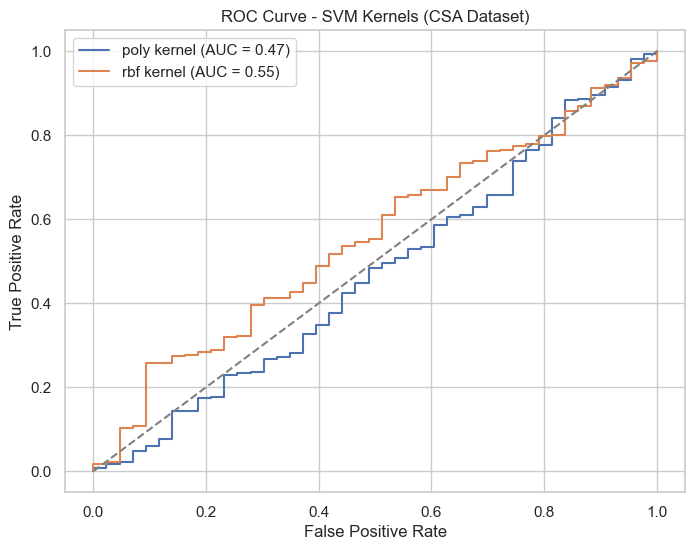

In [12]:
from sklearn.svm import SVC, OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, auc)
import matplotlib.pyplot as plt
import numpy as np

# =========================================
# CSA Dataset - SVM Workflow
# =========================================

# ------------------ 0. Feature Scaling ------------------
reg_csa = StandardScaler()
X_train_csa_reg = reg_csa.fit_transform(X_train_csa)
X_test_csa_reg = reg_csa.transform(X_test_csa)

# ------------------ 0b. Subsample for faster execution ------------------
sample_size = 10000
X_train_small_csa = X_train_csa_reg[:sample_size]
y_train_small_csa = y_train_csa[:sample_size]
X_test_small_csa = X_test_csa_reg[:sample_size]
y_test_small_csa = y_test_csa[:sample_size]

# =========================================
# 1. One-Class SVM (Anomaly Detection)
# =========================================
X_benign_csa = X_train_small_csa[y_train_small_csa == 0]  # train only on benign

ocsvm_csa = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
ocsvm_csa.fit(X_benign_csa)

y_pred_ocsvm_csa = ocsvm_csa.predict(X_test_small_csa)
y_pred_ocsvm_csa = np.where(y_pred_ocsvm_csa == 1, 0, 1)  # 0=benign, 1=anomaly

print("=== One-Class SVM (CSA) - Anomaly Detection ===")
print("Accuracy:", accuracy_score(y_test_small_csa, y_pred_ocsvm_csa))
print("Precision:", precision_score(y_test_small_csa, y_pred_ocsvm_csa))
print("Recall:", recall_score(y_test_small_csa, y_pred_ocsvm_csa))
print("F1-Score:", f1_score(y_test_small_csa, y_pred_ocsvm_csa))
print("ROC-AUC:", roc_auc_score(y_test_small_csa, y_pred_ocsvm_csa))
print("Confusion Matrix:\n", confusion_matrix(y_test_small_csa, y_pred_ocsvm_csa))

# =========================================
# 2. Supervised SVM (Attack Classification) with Hyperparameter Tuning
# =========================================
kernels = ['linear', 'poly', 'rbf']
results_csa = {}
fitted_clfs_csa = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'linear': {'C': [0.01, 0.1, 1, 10]},
    'poly': {'C': [0.01, 0.1, 1, 10], 'gamma': [0.01, 0.1, 1], 'degree': [2,3]},
    'rbf': {'C': [0.01, 0.1, 1, 10], 'gamma': [0.01, 0.1, 1]}
}

for kernel in kernels:
    svc = SVC(kernel=kernel, probability=True, random_state=42)
    grid = GridSearchCV(estimator=svc, param_grid=param_grid[kernel], 
                        cv=cv, scoring='f1', n_jobs=-1)
    grid.fit(X_train_small_csa, y_train_small_csa)

    clf = grid.best_estimator_
    y_pred = clf.predict(X_test_small_csa)
    y_prob = clf.predict_proba(X_test_small_csa)[:,1]

    fitted_clfs_csa[kernel] = clf
    results_csa[kernel] = {
        'Best Params': grid.best_params_,
        'Accuracy': accuracy_score(y_test_small_csa, y_pred),
        'Precision': precision_score(y_test_small_csa, y_pred),
        'Recall': recall_score(y_test_small_csa, y_pred),
        'F1-Score': f1_score(y_test_small_csa, y_pred),
        'Confusion Matrix': confusion_matrix(y_test_small_csa, y_pred),
        'Report': classification_report(y_test_small_csa, y_pred),
        'ROC-AUC': roc_auc_score(y_test_small_csa, y_prob)
    }

# Print results
for kernel, metrics in results_csa.items():
    print(f"\n=== Supervised SVM (CSA) with {kernel} kernel (GridSearchCV) ===")
    print("Best Hyperparameters:", metrics['Best Params'])
    for k, v in metrics.items():
        if k not in ['Confusion Matrix','Report','Best Params']:
            print(f"{k}: {v}")
    print("Confusion Matrix:\n", metrics['Confusion Matrix'])
    print("Classification Report:\n", metrics['Report'])

# =========================================
# 3. ROC Curves for Poly and RBF kernels
# =========================================
plt.figure(figsize=(8,6))

for kernel in ['poly','rbf']:
    clf = fitted_clfs_csa[kernel]
    y_prob = clf.predict_proba(X_test_small_csa)[:,1]
    fpr, tpr, _ = roc_curve(y_test_small_csa, y_prob)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{kernel} kernel (AUC = {roc_auc_val:.2f})')

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM Kernels (CSA Dataset)')
plt.legend()
plt.show()


## Dataset 3: UNSW - dataset
#### (i) Exploratory Data analysis 

In [13]:
# DATASET 3 : UNSW-NB15 Intrusion Detection Dataset
path = kagglehub.dataset_download("dhoogla/unswnb15")
df_unsw= pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))

unsw_numeric_columns=df_unsw.select_dtypes(include='number').columns

unsw_categorical_columns=df_unsw.select_dtypes(include=['object', 'category']).columns

# Combine training and test sets for preprocessing
df_unsw_combined = pd.concat([df_unsw, df_test_unsw], axis=0, ignore_index=True)

# Encode categorical columns
 
label_encoders = {}
for col in unsw_categorical_columns:
    le = LabelEncoder()
    df_unsw_combined[col] = le.fit_transform(df_unsw_combined[col].astype(str).fillna('Unknown'))
    label_encoders[col] = le

# Features and target (using 'lAabel' as the target variable)
X = df_unsw_combined[unsw_numeric_columns.tolist() + unsw_categorical_columns.tolist()].drop(columns=['label'])
y = df_unsw_combined['label']

#####################################################################Split into train and test sets
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


unsw_numeric=df_unsw_combined.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(unsw_numeric_columns)
print('\n')

unsw_categorical=df_unsw_combined.select_dtypes(include='object').columns
print("Categorical columns in the dataset:\n")
print(unsw_categorical_columns)
####################################################Regularize ##########################################################

reg_unsw = StandardScaler()
X_train_unsw_reg= reg_unsw.fit_transform(X_train)
X_test_unsw_reg = reg_unsw.transform(X_test)

X_train_unsw_df = pd.DataFrame(X_train, columns=X_train.columns)
X_train_unsw_reg_df = pd.DataFrame(X_train_unsw_reg, columns=X_train.columns)
X_test_unsw_df = pd.DataFrame(X_test, columns=X_test.columns)
X_test_unsw_reg_df = pd.DataFrame(X_test_unsw_reg, columns=X_test.columns)



##################### Normalize the features###################################################3
norm_unsw = MinMaxScaler()
X_train_norm_unsw = norm_unsw.fit_transform(X_train)
X_test_norm_unsw = norm_unsw.transform(X_test)

# Convert scaled features back to DataFrames
X_train_norm_unnsw_df = pd.DataFrame(X_train_norm_unsw, columns=X_train.columns)
X_test_norm_unsw_df = pd.DataFrame(X_test_norm_unsw, columns=X_train.columns)



Numeric columns in the dataset:

Index(['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload',
       'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb',
       'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean',
       'trans_depth', 'response_body_len', 'ct_src_dport_ltm',
       'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'is_sm_ips_ports', 'label'],
      dtype='object')


Categorical columns in the dataset:

Index(['proto', 'service', 'state', 'attack_cat'], dtype='object')


=== One-Class SVM (UNSW) - Anomaly Detection ===
Accuracy: 0.8272
Precision: 0.951733384409117
Recall: 0.7709852598913887
F1-Score: 0.8518772501285787
ROC-AUC: 0.8500495919710107
Confusion Matrix:
 [[3303  252]
 [1476 4969]]

=== Supervised SVM (UNSW) with linear kernel (GridSearchCV) ===
Best Hyperparameters: {'C': 1}
Accuracy: 0.9462
Precision: 0.9688839498333068
Recall: 0.9469356089992242
F1-Score: 0.9577840552416823
ROC-AUC: 0.9549357704868308
Confusion Matrix:
 [[3359  196]
 [ 342 6103]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93      3555
           1       0.97      0.95      0.96      6445

    accuracy                           0.95     10000
   macro avg       0.94      0.95      0.94     10000
weighted avg       0.95      0.95      0.95     10000


=== Supervised SVM (UNSW) with poly kernel (GridSearchCV) ===
Best Hyperparameters: {'C': 1, 'degree': 3, 'gamma': 1}
Accuracy: 0.9955
Precision: 0.99

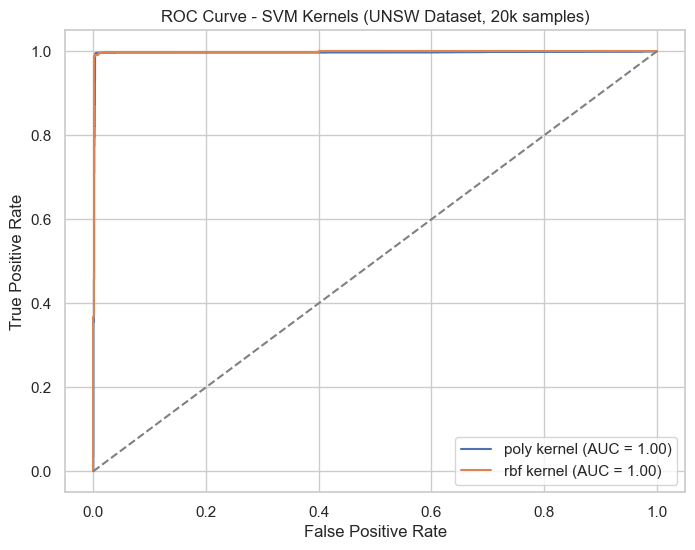

In [14]:
from sklearn.svm import SVC, OneClassSVM
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, roc_curve, auc)
import matplotlib.pyplot as plt
import numpy as np

# =========================================
# UNSW Dataset - SVM Workflow (20,000 samples) with Hyperparameter Tuning
# =========================================

# ------------------ 0. Subsample for faster execution ------------------
sample_size = 10000
X_train_small = X_train_unsw_reg[:sample_size]
y_train_small = y_train[:sample_size]
X_test_small = X_test_unsw_reg[:sample_size]
y_test_small = y_test[:sample_size]

# ------------------ 1. One-Class SVM (Anomaly Detection) ------------------
X_train_benign_small = X_train_small[y_train_small == 0]  # Train only on benign

ocsvm_unsw = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
ocsvm_unsw.fit(X_train_benign_small)

y_pred_ocsvm = ocsvm_unsw.predict(X_test_small)
y_pred_ocsvm = [0 if x == 1 else 1 for x in y_pred_ocsvm]  # 0=benign, 1=anomaly

print("=== One-Class SVM (UNSW) - Anomaly Detection ===")
print("Accuracy:", accuracy_score(y_test_small, y_pred_ocsvm))
print("Precision:", precision_score(y_test_small, y_pred_ocsvm))
print("Recall:", recall_score(y_test_small, y_pred_ocsvm))
print("F1-Score:", f1_score(y_test_small, y_pred_ocsvm))
print("ROC-AUC:", roc_auc_score(y_test_small, y_pred_ocsvm))
print("Confusion Matrix:\n", confusion_matrix(y_test_small, y_pred_ocsvm))

# ------------------ 2. Supervised SVM (Attack Classification) with Hyperparameter Tuning ------------------
kernels = ['linear', 'poly', 'rbf']
results_unsw = {}
fitted_clfs_unsw = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'linear': {'C': [0.01, 0.1, 1, 10]},
    'poly': {'C': [0.01, 0.1, 1, 10], 'gamma': [0.01, 0.1, 1], 'degree': [2,3]},
    'rbf': {'C': [0.01, 0.1, 1, 10], 'gamma': [0.01, 0.1, 1]}
}

for kernel in kernels:
    svc = SVC(kernel=kernel, probability=True, random_state=42)
    grid = GridSearchCV(estimator=svc, param_grid=param_grid[kernel], 
                        cv=cv, scoring='f1', n_jobs=-1)
    grid.fit(X_train_small, y_train_small)

    clf = grid.best_estimator_
    y_pred = clf.predict(X_test_small)
    y_prob = clf.predict_proba(X_test_small)[:,1]

    fitted_clfs_unsw[kernel] = clf
    results_unsw[kernel] = {
        'Best Params': grid.best_params_,
        'Accuracy': accuracy_score(y_test_small, y_pred),
        'Precision': precision_score(y_test_small, y_pred),
        'Recall': recall_score(y_test_small, y_pred),
        'F1-Score': f1_score(y_test_small, y_pred),
        'Confusion Matrix': confusion_matrix(y_test_small, y_pred),
        'Report': classification_report(y_test_small, y_pred),
        'ROC-AUC': roc_auc_score(y_test_small, y_prob)
    }

# Print metrics for each kernel
for kernel, metrics in results_unsw.items():
    print(f"\n=== Supervised SVM (UNSW) with {kernel} kernel (GridSearchCV) ===")
    print("Best Hyperparameters:", metrics['Best Params'])
    for k, v in metrics.items():
        if k not in ['Confusion Matrix','Report','Best Params']:
            print(f"{k}: {v}")
    print("Confusion Matrix:\n", metrics['Confusion Matrix'])
    print("Classification Report:\n", metrics['Report'])

# ------------------ 3. ROC Curves for Poly and RBF kernels ------------------
plt.figure(figsize=(8,6))
for kernel in ['poly','rbf']:
    clf = fitted_clfs_unsw[kernel]
    y_prob = clf.predict_proba(X_test_small)[:,1]
    fpr, tpr, _ = roc_curve(y_test_small, y_prob)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{kernel} kernel (AUC = {roc_auc_val:.2f})')

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM Kernels (UNSW Dataset, 20k samples)')
plt.legend()
plt.show()
